# 产量预测示例

In [8]:
import os

# 当 GPU 可用时，仅使用 1 个 GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline

# 加载 Chronos-2 pipeline
# device_map:
# - cpu: 使用CPU
# - cuda: 使用GPU
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cpu")

In [2]:
# 加载按日聚合后的生产数据
df = pd.read_csv("data/production_weekly.csv")

print("数据维度:", df.shape)
display(df.head())

# 将 production.csv 转换为 Chronos-2 所需的长表格式
chronos_df = pd.DataFrame({
    "item_id": "P",                     # 单条序列的 ID，可以按需修改
    "timestamp": df["日期"],        # 时间戳列
    "target": df["产量"].astype(float), # 预测目标列
})

# 按时间排序并重置索引，确保时间顺序正确
chronos_df = chronos_df.sort_values("timestamp").reset_index(drop=True)

print("Chronos-2 输入数据维度:", chronos_df.shape)
display(chronos_df.head())

数据维度: (54, 2)


,日期,产量
0,2025-03-03 00:00:00,76760
1,2025-03-10 00:00:00,77208
2,2025-03-17 00:00:00,73200
3,2025-03-24 00:00:00,76888
4,2025-03-31 00:00:00,69584


Chronos-2 输入数据维度: (54, 3)


,item_id,timestamp,target
0,P,2025-03-03 00:00:00,76760.0
1,P,2025-03-10 00:00:00,77208.0
2,P,2025-03-17 00:00:00,73200.0
3,P,2025-03-24 00:00:00,76888.0
4,P,2025-03-31 00:00:00,69584.0


In [3]:
# 使用前 80% 作为上下文，后 20% 作为测试集，便于对比预测效果
context_ratio = 0.8
split_index = int(len(chronos_df) * context_ratio)

context_df = chronos_df.iloc[:split_index].reset_index(drop=True)
test_df = chronos_df.iloc[split_index:].reset_index(drop=True)

print(f"上下文（前 {int(context_ratio*100)}%）：{len(context_df)} 行，测试集（后 {int((1-context_ratio)*100)}%）：{len(test_df)} 行")
print("上下文示例:")
display(context_df.head())
print("测试集示例:")
display(test_df.head())

上下文（前 80%）：43 行，测试集（后 19%）：11 行
上下文示例:


,item_id,timestamp,target
0,P,2025-03-03 00:00:00,76760.0
1,P,2025-03-10 00:00:00,77208.0
2,P,2025-03-17 00:00:00,73200.0
3,P,2025-03-24 00:00:00,76888.0
4,P,2025-03-31 00:00:00,69584.0


测试集示例:


,item_id,timestamp,target
0,P,2025-12-29 00:00:00,132528.0
1,P,2026-01-05 00:00:00,126072.0
2,P,2026-01-12 00:00:00,129120.0
3,P,2026-01-19 00:00:00,127088.0
4,P,2026-01-26 00:00:00,112912.0


预测结果维度: (11, 7)


,item_id,timestamp,target_name,predictions,0.1,0.5,0.9
0,P,2025-12-29,target,58995.824219,34919.710938,58995.824219,83553.453125
1,P,2026-01-05,target,58805.308594,33160.871094,58805.308594,85602.609375
2,P,2026-01-12,target,60251.898438,31974.251953,60251.898438,87503.710938
3,P,2026-01-19,target,60151.320312,32848.054688,60151.320312,88616.085938
4,P,2026-01-26,target,60422.605469,31210.833984,60422.605469,89999.429688


/tmp/ipykernel_18651/633466350.py:53: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18651/633466350.py:53: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18651/633466350.py:53: UserWarning: Glyph 20135 (\N{CJK UNIFIED IDEOGRAPH-4EA7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18651/633466350.py:53: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18651/633466350.py:53: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18651/633466350.py:53: UserWarning: Glyph 21490 (\N{CJK UNIFIED IDEOGRAPH-53F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_18651/633466350.py:53: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}

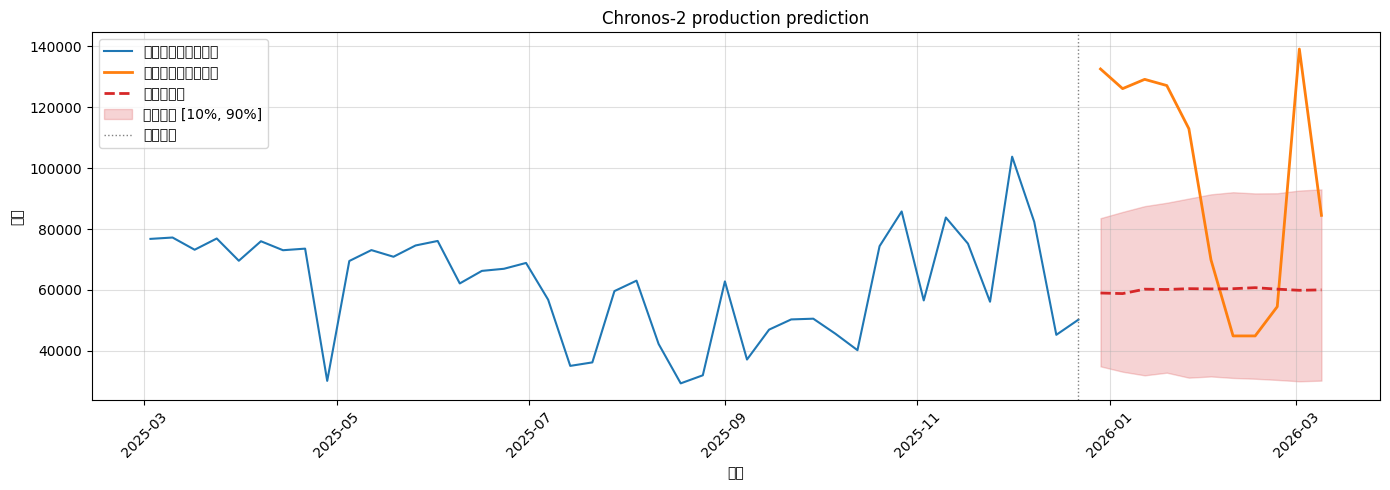

In [7]:
# 使用 Chronos-2 进行预测，并与测试集真实值对比
pred_df = pipeline.predict_df(
    context_df,
    prediction_length=len(test_df),
    quantile_levels=[0.1, 0.5, 0.9],
)

print("预测结果维度:", pred_df.shape)
display(pred_df.head())

item_id = "P"

# context_df / test_df 的 timestamp 列由 CSV 读入为字符串，需显式转为 datetime，
# 否则 matplotlib 会将其识别为 categorical，与 pred_df 中的 DatetimeIndex 混用时
# 抛出 TypeError: tz must be string or tzinfo subclass
ts_context = context_df.query("item_id == @item_id").set_index("timestamp")["target"]
ts_context.index = pd.to_datetime(ts_context.index)

ts_test = test_df.query("item_id == @item_id").set_index("timestamp")["target"]
ts_test.index = pd.to_datetime(ts_test.index)

# 提取预测结果：中位数 (predictions 即 0.5 分位数) + 置信区间 [0.1, 0.9]
ts_pred = (
    pred_df
    .query("item_id == @item_id and target_name == 'target'")
    .set_index("timestamp")[["0.1", "predictions", "0.9"]]
)

plt.figure(figsize=(14, 5))
plt.plot(ts_context.index, ts_context.values,
         label="历史产量（上下文）", color="C0", linewidth=1.5)
plt.plot(ts_test.index, ts_test.values,
         label="真实产量（测试集）", color="C1", linewidth=2)
plt.plot(ts_pred.index, ts_pred["predictions"].values,
         label="预测中位数", color="C3", linewidth=2, linestyle="--")
plt.fill_between(
    ts_pred.index,
    ts_pred["0.1"].values,
    ts_pred["0.9"].values,
    color="C3",
    alpha=0.2,
    label="预测区间 [10%, 90%]",
)
plt.axvline(x=ts_context.index[-1], color="gray", linestyle=":", linewidth=1,
            label="预测起点")

plt.title("Chronos-2 production prediction")
plt.xlabel("日期")
plt.ylabel("产量")
plt.grid(True, alpha=0.4)
plt.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

发现预测结果非常不准，原因是：
- 样本未包含数据波动较大的春节期间的数据，看起来春节期间设备产量更高
- 数据几乎没有按照时间变化的规律，导致预测结果是一条水平线